# Analyzing 5K PBMC dataset from 10X genomics

## Table of contents

1. [Introduction](#introduction)
2. [Setup](#setup)
3. [Preprocessing](#preprocessing)
4. [Dimension reduction](#dimension_reduction)
5. [Clustering analysis](#clustering)
6. [Cluster annotation](#annotation)

## Introduction <a name="introduction"></a>
Some introduction text

## Import library and environment setup <a name="setup"></a>

In [1]:
import snapatac2 as snap
import numpy as np

The fragment file can be download from 10X genomics website. We also need a gene annotation file which can be downloaded from Gencode.

In [2]:
# Input files
fragment_file = "data/atac_pbmc_5k_nextgem_fragments.tsv.gz"
gene_annotation = "data/gencode.v39.basic.annotation.gff3.gz"

## Preprocessing <a name="preprocessing"></a>

We start off on data preprocessing by importing the fragment files and generate a cell by window matrix. The resulting matrix will be stored in anndata format. Click HERE to learn more about this format.

During this process, various quality controls, such as TSS enrichment, the number of unique fragments per cell, will also be computed and store in the anndata.

In [3]:
%%time
data = snap.pp.make_tile_matrix(
    "count_matrix.h5ad",
    fragment_file,
    gene_annotation,
    snap.genome.hg38,
    sorted_by_barcode=False,
)
data

CPU times: user 9min 9s, sys: 14.5 s, total: 9min 24s
Wall time: 9min 14s


AnnData object with n_obs × n_vars = 14227 × 6176550
    obs: 'tsse', 'n_fragment', 'frac_dup', 'frac_mito'

We next plot TSS enrichment against number of unique fragments for each cell. Based on the plot, we decided to retain those cells that 

In [ ]:
snap.pl.tsse(data)

The cells on the upper right corresponds to valid cells, while the cells on the lower left corresponds to low-quality cells or empty dropblets. According to this plot, we decided to choose minimum TSS enrichment of 10 and minimum number of fragments of 5000 to filter the cells.

In [8]:
snap.pp.filter_cells(data, min_counts=5000, min_tsse=10, max_counts=100000)
data

AnnData object with n_obs × n_vars = 4564 × 6176550
    obs: 'tsse', 'n_fragment', 'frac_dup', 'frac_mito'

In [9]:
# Feature selection
features = snap.pp.select_features(data)

### Doublet removal

Here we apply a customized scrublet algorithm to identify potential doublets.

In [11]:
%%time
snap.pp.scrublet(data, features=features)

Simulating doublets...
Spectral embedding ...
Compute similarity matrix
Normalization
Perform decomposition
Calculating doublet scores...
CPU times: user 5min 48s, sys: 1min 49s, total: 7min 38s
Wall time: 3min 23s


In [12]:
data = data[data.obs["doublet_probability"] < 0.5, ]

## Dimenstion reduction <a name="dimension_reduction"></a>

In [13]:
%%time
snap.tl.spectral(data, features=features)

Compute similarity matrix
Normalization
Perform decomposition


Trying to set attribute `._uns` of view, copying.


CPU times: user 1min 59s, sys: 38.8 s, total: 2min 37s
Wall time: 43.9 s


In [14]:
%%time
snap.tl.umap(data)

/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn("Tensorflow not installed; ParametricUMAP will be unavailable")


CPU times: user 49.2 s, sys: 482 ms, total: 49.7 s
Wall time: 50.5 s


## Clustering analysis <a name="clustering"></a>

In [68]:
%%time
snap.pp.knn(data)
snap.tl.leiden(data, objective_function="modularity")
snap.tl.kmeans(data, 12)

CPU times: user 6.16 s, sys: 158 ms, total: 6.31 s
Wall time: 1.62 s


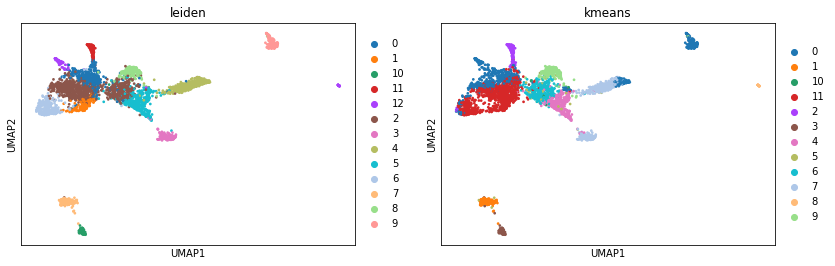

In [69]:
import scanpy as sc
sc.pl.umap(data, color=["leiden", "kmeans"])

In [17]:
data.write("pbmc_atac.h5ad")

## Cell cluster annotation <a name="annotation"></a>

### Create the cell by gene activity matrix

In [59]:
%%time
data = snap.read("pbmc_atac.h5ad", backed="r") # backed mode is required for calling make_gene_matrix
gene_matrix = snap.pp.make_gene_matrix(data, gene_annotation)
gene_matrix

CPU times: user 8min 26s, sys: 6.77 s, total: 8min 33s
Wall time: 1min 54s


AnnData object with n_obs × n_vars = 4053 × 60286
    obs: 'tsse', 'n_fragment', 'frac_dup', 'frac_mito', 'doublet_probability', 'leiden', 'kmeans'
    obsm: 'X_spectral', 'X_umap'

### Imputation

In [60]:
import scanpy as sc

sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [61]:
%%time
sc.external.pp.magic(gene_matrix, solver="approximate")

CPU times: user 49.5 s, sys: 1.95 s, total: 51.4 s
Wall time: 43.8 s


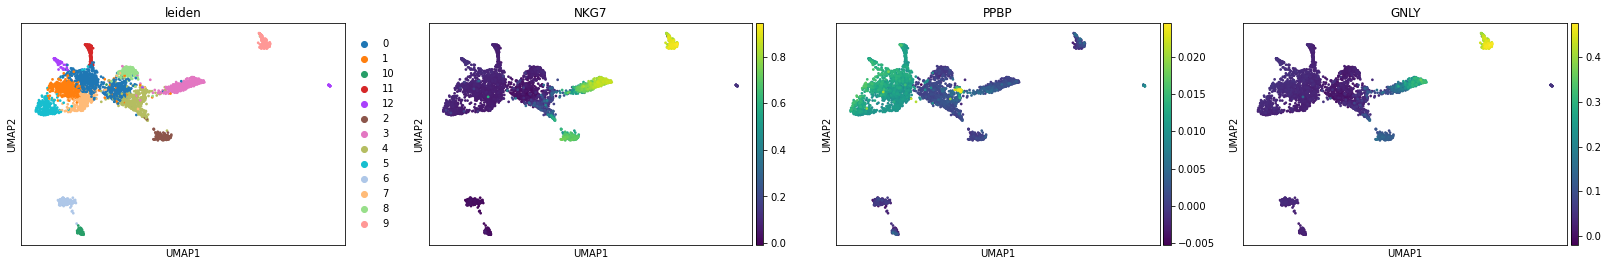

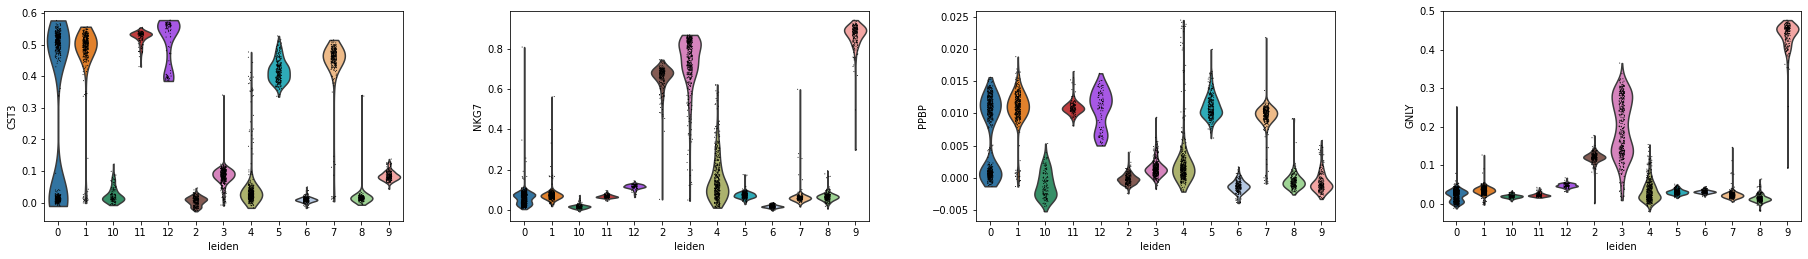

In [63]:
sc.pl.umap(gene_matrix, use_raw=False, color=["leiden", "NKG7", "PPBP", "GNLY"])
sc.pl.violin(gene_matrix, ['CST3', 'NKG7', 'PPBP', "GNLY"], use_raw=False, groupby='leiden')